# Task A pipeline manual validation

This notebook validates the Costa Rican electrical-grid data pipeline step by step:
loading the static ICE snapshots, parsing substations and generators, building the
weighted NetworkX national graph, assigning generators to substations, inspecting
generation-aware edge weights, extracting the `GUANACASTE_NORTH` subgrid,
visualizing it, and serializing it to the `grid_cr.json` schema.

## 1. Imports and repository path setup

The notebook lives in `notebooks/`, so it adds the repository root to `sys.path`
before importing modules from `src`.

In [1]:
import json
import math
import os
import sys
from collections import Counter
from pathlib import Path

# Required path setup when running from notebooks/.
sys.path.insert(0, os.path.abspath('..'))
repo_root = Path(os.path.abspath('..'))

# Robust fallback when the executor keeps the current working directory at repo root.
if not (repo_root / 'src').exists():
    repo_root = Path.cwd()
    sys.path.insert(0, str(repo_root))

from IPython.display import Image, display
import networkx as nx

from src import graph, ice_data, weights

print(f'Repository root: {repo_root}')
print(f'Default weight scheme: {weights.DEFAULT_SCHEME}')
print(f'Available schemes: {sorted(weights.SCHEMES)}')
assert weights.DEFAULT_SCHEME == 'generation'

Repository root: Q:\src\kraken-team-quantathon
Default weight scheme: generation
Available schemes: ['generation', 'kv', 'kv_normalized', 'kv_over_length']


## 2. Load ICE snapshots

Load the three static GeoJSON snapshots used by the reproducible pipeline and
print their feature counts.

In [2]:
subs = ice_data.load_snapshot('substations')
lines = ice_data.load_snapshot('lines')
plants = ice_data.load_snapshot('plants')

snapshot_counts = {
    'substations': len(subs.get('features', [])),
    'lines': len(lines.get('features', [])),
    'plants': len(plants.get('features', [])),
}
print(json.dumps(snapshot_counts, indent=2, ensure_ascii=False))
assert all(count > 0 for count in snapshot_counts.values())

{
  "substations": 70,
  "lines": 102,
  "plants": 32
}


## 3. Parse generators and validate thermal classification

Parse active plants into generator records, summarize technologies, and verify the
thermal rule: `Térmico` is thermal, while `Geotérmico` is not thermal.

In [3]:
generators = graph.parse_generators(plants)
tech_counts = Counter(g['technology'] for g in generators)
thermal_counts = Counter(g['technology'] for g in generators if graph.is_thermal(g['technology']))

print(f'Active generators parsed: {len(generators)}')
print('\nCounts by technology:')
for tech, count in sorted(tech_counts.items(), key=lambda item: (str(item[0]), item[1])):
    print(f'  {tech}: {count}')

print('\nThermal counts by technology:')
for tech, count in sorted(thermal_counts.items(), key=lambda item: (str(item[0]), item[1])):
    print(f'  {tech}: {count}')

print('\nRule checks:')
print(f"  is_thermal('Térmico') = {graph.is_thermal('Térmico')}")
print(f"  is_thermal('Geotérmico') = {graph.is_thermal('Geotérmico')}")
assert graph.is_thermal('Térmico') is True
assert graph.is_thermal('Geotérmico') is False
assert all(g['thermal'] == graph.is_thermal(g['technology']) for g in generators)

Active generators parsed: 32

Counts by technology:
  Eólico: 1
  Geotérmico: 7
  Hidroeléctrico: 18
  Solar: 1
  Térmico: 5

Thermal counts by technology:
  Térmico: 5

Rule checks:
  is_thermal('Térmico') = True
  is_thermal('Geotérmico') = False


## 4. Build the national graph with generation data

Build the weighted national graph with `plants_geojson=plants`, then inspect the
node/edge counts and the build report.

In [4]:
G, report = graph.build_national_graph(subs, lines, plants_geojson=plants)
print(f'National graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(json.dumps(report, indent=2, ensure_ascii=False))
assert G.number_of_nodes() == report['n_nodes']
assert G.number_of_edges() == report['n_edges']

National graph: 75 nodes, 97 edges
{
  "unrecognized_endpoints": [
    "aguas calientes",
    "cemex",
    "changuinola",
    "frontera nicaragua",
    "progreso"
  ],
  "ignored_circuits": [
    "SIEPAC"
  ],
  "n_nodes": 75,
  "n_edges": 97
}


## 5. Inspect generator assignment

Find a substation with nearby generators and print its attached generator list,
`n_generators`, and `n_thermal` attributes.

In [5]:
preferred = ['miravalles', 'pailas']
node_with_generators = next((n for n in preferred if n in G and G.nodes[n].get('n_generators', 0) > 0), None)
if node_with_generators is None:
    node_with_generators = next(n for n, d in G.nodes(data=True) if d.get('n_generators', 0) > 0)

attrs = G.nodes[node_with_generators]
print(f'Node: {node_with_generators} ({attrs.get("name")})')
print(f"n_generators = {attrs.get('n_generators')}")
print(f"n_thermal = {attrs.get('n_thermal')}")
print(json.dumps(attrs.get('generators', []), indent=2, ensure_ascii=False))
assert attrs['n_generators'] == len(attrs['generators'])
assert attrs['n_thermal'] == sum(1 for g in attrs['generators'] if g['thermal'])

Node: miravalles (Miravalles)
n_generators = 8
n_thermal = 0
[
  {
    "plant": "Miravalles I",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 42.38,
    "dist_m": 117.0
  },
  {
    "plant": "Miravalles II",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 42.32,
    "dist_m": 122.0
  },
  {
    "plant": "Miravalles V",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 6,
    "dist_m": 1968.9
  },
  {
    "plant": "Miravalles III",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 27.02,
    "dist_m": 2221.7
  },
  {
    "plant": "Miravalles Solar",
    "technology": "Solar",
    "thermal": false,
    "power_mw": 1,
    "dist_m": 2372.6
  },
  {
    "plant": "Boca Pozo",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 5,
    "dist_m": 3555.0
  },
  {
    "plant": "Pailas II",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 52,
    "dist_m": 17877.6
  },
  {
 

## 6. Inspect generation-aware edge weights

Generation weight formula:

\[
weight = 1 + n_{gen}(u) + n_{gen}(v)
- 0.5 \cdot [\text{both endpoints have at least one generator}]
- \sum_{k=1}^{T} 0.5^k
+ \frac{voltage}{1000}
\]

where `T` is the number of thermal generators across both endpoints. In this
project, thermal means technology `Térmico`; geothermal (`Geotérmico`) is not
thermal.

In [6]:
def edge_components(u, v, d):
    gens_u = G.nodes[u].get('generators', [])
    gens_v = G.nodes[v].get('generators', [])
    t = G.nodes[u].get('n_thermal', 0) + G.nodes[v].get('n_thermal', 0)
    both_penalty = 0.5 if gens_u and gens_v else 0.0
    thermal_penalty = sum(0.5 ** k for k in range(1, t + 1))
    expected = 1 + len(gens_u) + len(gens_v) - both_penalty - thermal_penalty + d.get('voltage', 0) / 1000
    return {
        'u': u,
        'v': v,
        'voltage': d.get('voltage'),
        'n_gen_u': len(gens_u),
        'n_gen_v': len(gens_v),
        'n_thermal_u': G.nodes[u].get('n_thermal', 0),
        'n_thermal_v': G.nodes[v].get('n_thermal', 0),
        'both_generator_penalty': both_penalty,
        'thermal_halving_penalty': thermal_penalty,
        'weight': d.get('weight'),
        'expected_formula_weight': expected,
    }

thermal_edges = [(u, v, d) for u, v, d in G.edges(data=True)
                 if G.nodes[u].get('n_thermal', 0) + G.nodes[v].get('n_thermal', 0) > 0]
nonthermal_edges = [(u, v, d) for u, v, d in G.edges(data=True)
                    if G.nodes[u].get('n_generators', 0) + G.nodes[v].get('n_generators', 0) > 0
                    and G.nodes[u].get('n_thermal', 0) + G.nodes[v].get('n_thermal', 0) == 0]
plain_edges = [(u, v, d) for u, v, d in G.edges(data=True)
               if G.nodes[u].get('n_generators', 0) + G.nodes[v].get('n_generators', 0) == 0]

samples = []
if thermal_edges:
    samples.append(thermal_edges[0])
samples.extend(nonthermal_edges[:2])
samples.extend(plain_edges[: max(0, 3 - len(samples))])

for item in samples[:5]:
    components = edge_components(*item)
    print(json.dumps(components, indent=2, ensure_ascii=False))
    assert math.isclose(components['weight'], components['expected_formula_weight'], rel_tol=1e-9)

if thermal_edges:
    print('\nThermal edge found above: the halving penalty is shown in thermal_halving_penalty.')
else:
    demo_weight = weights.SCHEMES['generation'](
        voltage=138,
        length_m=1000,
        gens_u=[{'thermal': True}, {'thermal': True}],
        gens_v=[{'thermal': False}],
    )
    expected = 1 + 2 + 1 - 0.5 - (0.5 + 0.25) + 138 / 1000
    print('\nNo real thermal edge was found; synthetic thermal demonstration:')
    print('Expected = 1 + 2 + 1 - 0.5 - (0.5 + 0.25) + 0.138 =', expected)
    print('Function result =', demo_weight)
    assert math.isclose(demo_weight, expected, rel_tol=1e-9)

{
  "u": "moin",
  "v": "trapiche",
  "voltage": 230,
  "n_gen_u": 2,
  "n_gen_v": 1,
  "n_thermal_u": 2,
  "n_thermal_v": 0,
  "both_generator_penalty": 0.5,
  "thermal_halving_penalty": 0.75,
  "weight": 2.98,
  "expected_formula_weight": 2.98
}
{
  "u": "pailas",
  "v": "liberia",
  "voltage": 230,
  "n_gen_u": 6,
  "n_gen_v": 2,
  "n_thermal_u": 0,
  "n_thermal_v": 0,
  "both_generator_penalty": 0.5,
  "thermal_halving_penalty": 0,
  "weight": 8.73,
  "expected_formula_weight": 8.73
}
{
  "u": "pailas",
  "v": "mogote",
  "voltage": 230,
  "n_gen_u": 6,
  "n_gen_v": 8,
  "n_thermal_u": 0,
  "n_thermal_v": 0,
  "both_generator_penalty": 0.5,
  "thermal_halving_penalty": 0,
  "weight": 14.73,
  "expected_formula_weight": 14.73
}

Thermal edge found above: the halving penalty is shown in thermal_halving_penalty.


## 7. Extract the `GUANACASTE_NORTH` subgrid

Extract the default nine-node Guanacaste North subgrid, print its nodes, edges,
independent cycle count, and edge weights.

In [7]:
sub = graph.extract_subregion(G, nodes=graph.GUANACASTE_NORTH, max_nodes=len(graph.GUANACASTE_NORTH))
cycles = sub.number_of_edges() - sub.number_of_nodes() + nx.number_connected_components(sub)

print(f'Subgrid: {sub.number_of_nodes()} nodes, {sub.number_of_edges()} edges, {cycles} independent cycle(s)')
print('Nodes:')
for n in sorted(sub.nodes):
    print(f'  {n}')

print('\nEdges:')
for u, v, d in sorted(sub.edges(data=True)):
    print(f"  {u} -- {v}: weight={d['weight']:.3f}, voltage={d.get('voltage')}, circuit={d.get('circuit')}")

assert set(sub.nodes).issubset(set(graph.GUANACASTE_NORTH))
assert nx.is_connected(sub)

Subgrid: 9 nodes, 9 edges, 1 independent cycle(s)
Nodes:
  arenal
  canas
  corobici
  liberia
  miravalles
  mogote
  nuevo colon
  pailas
  papagayo

Edges:
  corobici -- arenal: weight=8.730, voltage=230, circuit=Arenal-Corobici
  corobici -- canas: weight=8.730, voltage=230, circuit=Corobici-Canas
  liberia -- canas: weight=6.730, voltage=230, circuit=Canas-Liberia
  miravalles -- arenal: weight=12.730, voltage=230, circuit=Miravalles-Arenal
  mogote -- miravalles: weight=16.730, voltage=230, circuit=Miravalles-Mogote
  pailas -- liberia: weight=8.730, voltage=230, circuit=Pailas-Liberia
  pailas -- mogote: weight=14.730, voltage=230, circuit=Mogote-Pailas
  papagayo -- liberia: weight=3.230, voltage=230, circuit=Liberia-Papagayo
  papagayo -- nuevo colon: weight=1.230, voltage=230, circuit=Papagayo-Nuevo Colon


## 8. Visualize the subgrid inline

Create a validation figure with the repository visualization helper and display it
inline.

Wrote Q:\src\kraken-team-quantathon\figures\validation_subgrid.png


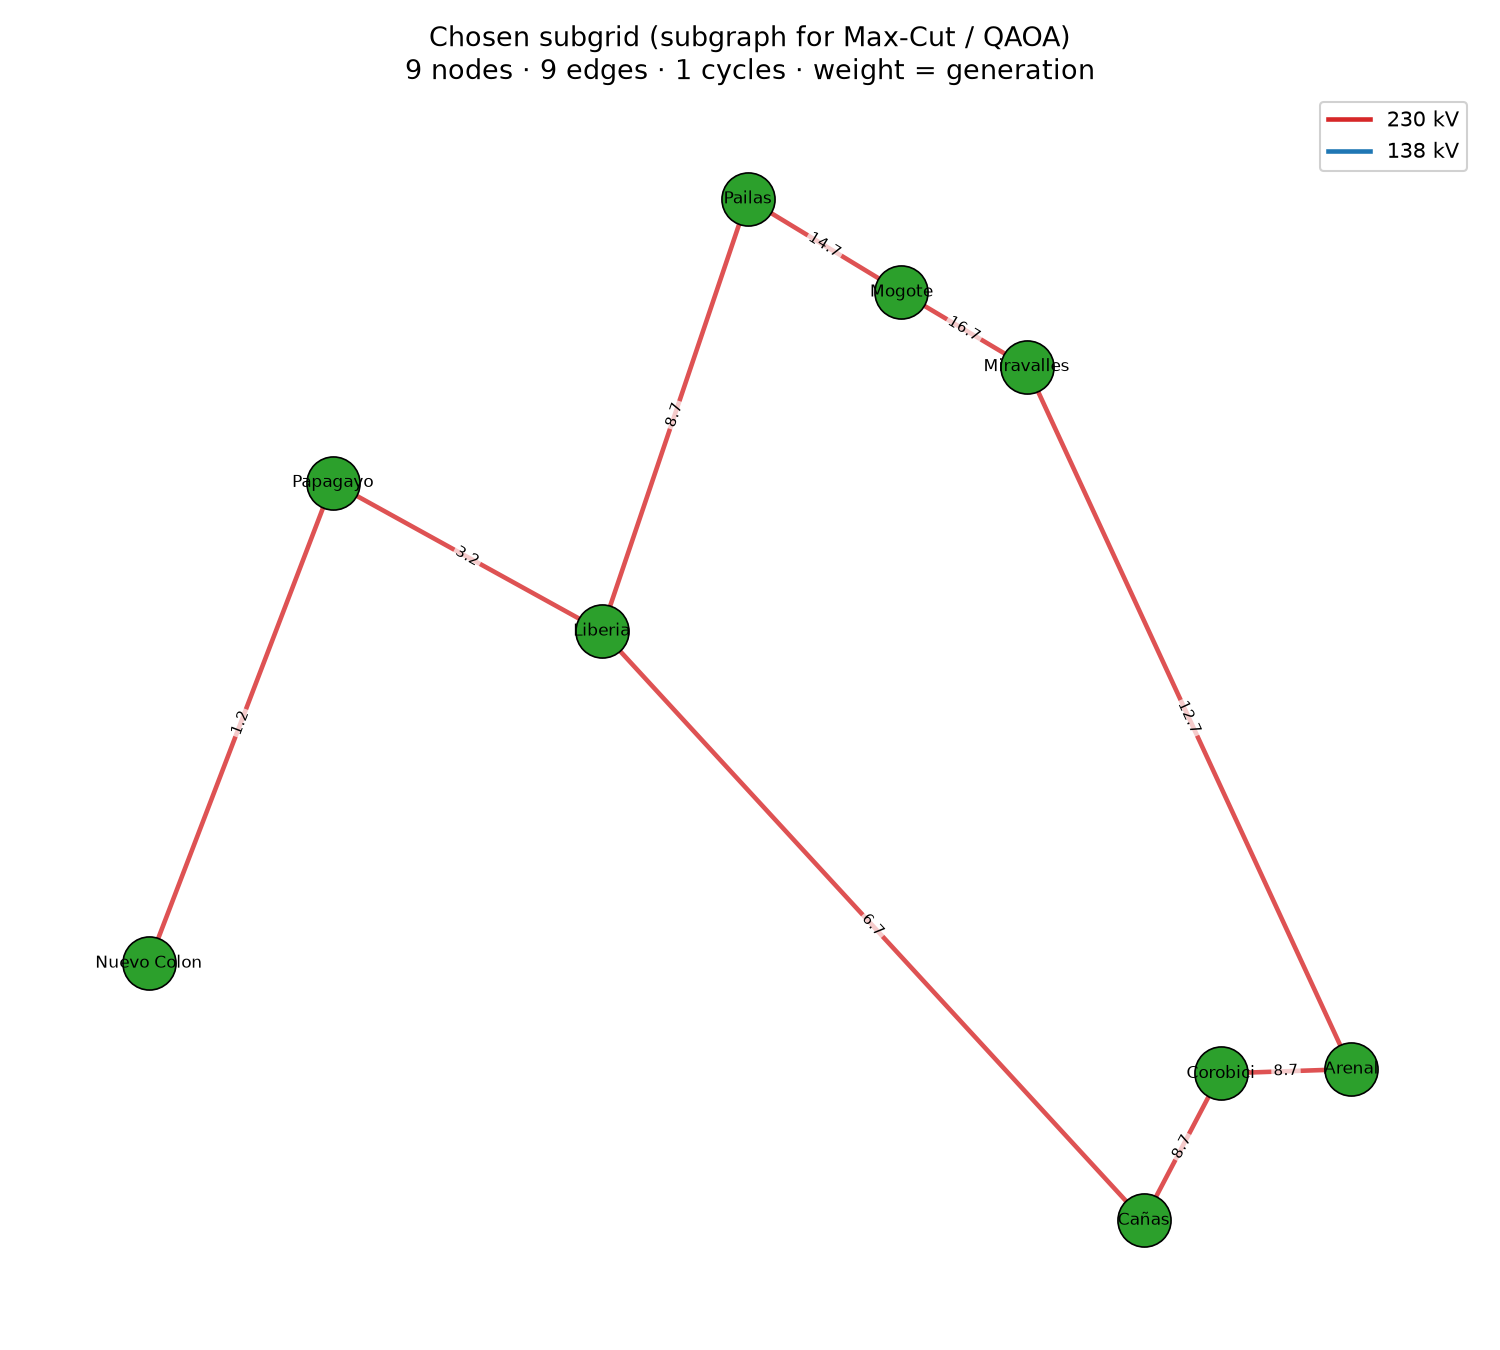

In [8]:
from src import visualize

figure_path = repo_root / 'figures' / 'validation_subgrid.png'
visualize.plot_subgraph(sub, out=figure_path)
print(f'Wrote {figure_path}')
display(Image(filename=str(figure_path)))
assert figure_path.exists()

## 9. Serialize the subgrid

Serialize with `graph.to_json`, then show one node containing generators (if the
subgrid has one) and one edge in the output schema.

In [9]:
doc = graph.to_json(sub, metadata={
    'purpose': 'manual validation notebook',
    'weight_scheme': weights.DEFAULT_SCHEME,
    'region': 'guanacaste_north',
    'independent_cycles': cycles,
})

node_example = next((node for node in doc['nodes'] if node.get('generators')), doc['nodes'][0] if doc['nodes'] else None)
edge_example = doc['edges'][0] if doc['edges'] else None

print('Top-level keys:', sorted(doc.keys()))
print('\nNode example:')
print(json.dumps(node_example, indent=2, ensure_ascii=False))
print('\nEdge example:')
print(json.dumps(edge_example, indent=2, ensure_ascii=False))

assert set(doc.keys()) == {'metadata', 'nodes', 'edges'}
assert len(doc['nodes']) == sub.number_of_nodes()
assert len(doc['edges']) == sub.number_of_edges()

Top-level keys: ['edges', 'metadata', 'nodes']

Node example:
{
  "id": "corobici",
  "name": "Corobici",
  "province": "Guanacaste",
  "canton": "Cañas",
  "x": -85.0778213507225,
  "y": 10.4712932222768,
  "border": false,
  "generators": [
    {
      "plant": "Dengo",
      "technology": "Hidroeléctrico",
      "thermal": false,
      "power_mw": 174.01,
      "dist_m": 257.9
    },
    {
      "plant": "Sandillal",
      "technology": "Hidroeléctrico",
      "thermal": false,
      "power_mw": 30.97,
      "dist_m": 2898.2
    },
    {
      "plant": "Arenal",
      "technology": "Hidroeléctrico",
      "thermal": false,
      "power_mw": 166,
      "dist_m": 8653.9
    },
    {
      "plant": "Tejona",
      "technology": "Eólico",
      "thermal": false,
      "power_mw": 13.2,
      "dist_m": 11131.4
    }
  ],
  "n_generators": 4,
  "n_thermal": 0
}

Edge example:
{
  "u": "corobici",
  "v": "canas",
  "weight": 8.73,
  "voltage": 230,
  "circuit": "Corobici-Canas"
}


## 10. Manual validation checklist

Validated in this notebook:

- Static ICE snapshots load from `data/raw/`.
- Active generation plants parse correctly.
- Thermal classification treats `Térmico` as thermal and `Geotérmico` as non-thermal.
- The national graph builds with generator assignments and the `generation` weight scheme.
- Edge weights match the documented generation formula, including the thermal halving penalty when applicable.
- The `GUANACASTE_NORTH` subgrid is connected and has an independent cycle count.
- The subgrid can be visualized and serialized to the expected JSON schema.